# Dataset Loading

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
import pandas as pd
from config.paths import STEAM_RECOMMENDATIONS_PATH, SAMPLE_GRAPH_OUTPUT_PATH, SAMPLE_GRAPH_VISUAL_OUTPUT_PATH

In [3]:
def load_recommendations_data():
    df_reviews = pd.read_csv(
        STEAM_RECOMMENDATIONS_PATH,
        usecols=["user_id", "app_id", "is_recommended"]
    )

    # Keep only positive recommendations
    df_reviews = df_reviews[
        df_reviews["is_recommended"] == True
    ]

    # Drop recommendation flag after filtering
    df_reviews = df_reviews.drop(
        columns=["is_recommended"]
    )

    return df_reviews

df_reviews = load_recommendations_data()
df_reviews.head()

,app_id,user_id
0,975370,51580
2,1085660,253880
3,703080,259432
4,526870,23869
5,306130,45425


# Data Preprocessing

This section applies filtering and cleaning steps to improve the quality of the graph representation.
The main goal is to reduce noise and keep only meaningful user–game interactions.

In [4]:
def preprocess_recommendations_data(
    df_reviews: pd.DataFrame
) -> pd.DataFrame:
    # Remove rows with missing values
    df_reviews = df_reviews.dropna(
        subset=["user_id", "app_id"]
    )

    # Remove duplicate user-game reviews
    df_reviews = df_reviews.drop_duplicates(
        subset=["user_id", "app_id"]
    )

    return df_reviews


df_reviews = preprocess_recommendations_data(df_reviews)

print(f"Total reviews rows: {len(df_reviews)}")
print(f"Unique users: {df_reviews['user_id'].nunique()}")
print(f"Unique games: {df_reviews['app_id'].nunique()}")

df_reviews.head()

Total reviews rows: 35304383
Unique users: 12663134
Unique games: 37419


,app_id,user_id
0,975370,51580
2,1085660,253880
3,703080,259432
4,526870,23869
5,306130,45425


# Graph Construction

In [5]:
def sample_reviews_by_users(
    df_reviews: pd.DataFrame,
    sample_fraction: float = 0.1,
    random_state: int = 42
) -> pd.DataFrame:
    # sample users
    sampled_users = (
        df_reviews["user_id"]
        .drop_duplicates()
        .sample(
            frac=sample_fraction,
            random_state=random_state
        )
    )

    # keep all rows from sampled users
    df_sample = df_reviews[
        df_reviews["user_id"].isin(sampled_users)
    ].copy()

    return df_sample

df_sample = sample_reviews_by_users(df_reviews)

In [6]:
import networkx as nx
from itertools import combinations
from collections import defaultdict

def build_game_similarity_graph(
    df_reviews_sample: pd.DataFrame,
    min_common_users: int = 5
) -> nx.Graph:
    # Group all recommended games by sampled user
    user_games = (
        df_reviews_sample
        .groupby("user_id")["app_id"]
        .apply(list)
    )

    # Count common users for each game pair
    pair_counts = defaultdict(int)

    for games in user_games:
        unique_games = list(set(games))

        if len(unique_games) < 2:
            continue

        for game_1, game_2 in combinations(
            sorted(unique_games), 2
        ):
            pair_counts[(game_1, game_2)] += 1

    # Create graph
    G = nx.Graph()

    # Add all games in sample as nodes
    G.add_nodes_from(
        df_reviews_sample["app_id"].unique()
    )

    # Add weighted edges using threshold
    for (game_1, game_2), common_users in pair_counts.items():
        if common_users >= min_common_users:
            G.add_edge(
                game_1,
                game_2,
                weight=common_users
            )

    return G


G = build_game_similarity_graph(
    df_sample,
    min_common_users=5
)

print(f"Nodes (games): {G.number_of_nodes()}")
print(f"Edges (pairwise recommendations): {G.number_of_edges()}")

Nodes (games): 30063
Edges (pairwise recommendations): 807611


# Initial Analysis

### Graph Size and Average Degree

This cell computes the main structural properties of the graph created from the sampled Steam recommendation data.

The number of nodes represents the total number of unique games in the sampled dataset.

The number of edges represents the number of game pairs that share at least five common recommending users.

The average degree indicates, on average, how many similar games each game is connected to in the graph.

In [7]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

average_degree = (2 * num_edges) / num_nodes

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Average degree: {average_degree:.2f}")

Number of nodes: 30063
Number of edges: 807611
Average degree: 53.73


### Degree Distribution Analysis

This cell visualizes the degree distribution of the graph.

The degree of a node corresponds to the number of other games connected to it through shared user recommendations.

This analysis helps identify whether the graph contains highly connected games (hub nodes) and whether the connectivity follows a sparse or dense structure.

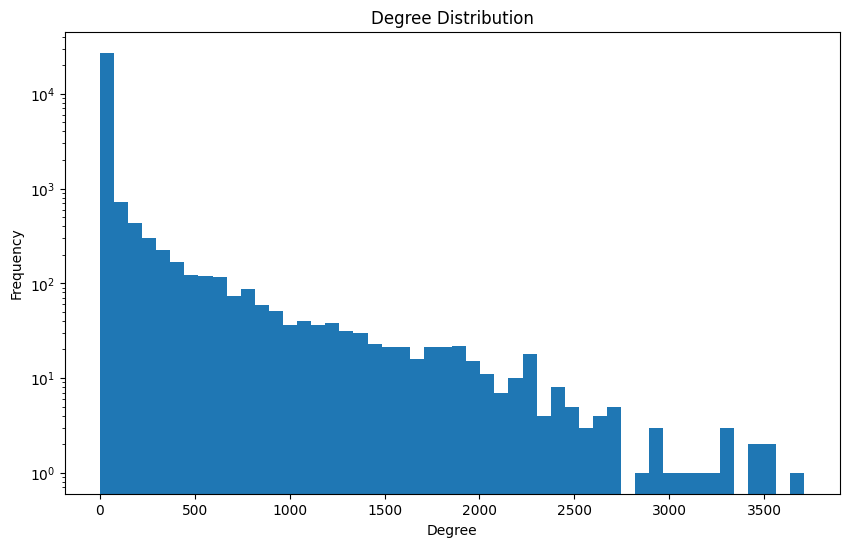

In [8]:
import matplotlib.pyplot as plt

degrees = [degree for _, degree in G.degree()]

plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=50)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution")
plt.yscale("log")
plt.show()

### Connected Components

This cell calculates the number of connected components in the graph.

A connected component is a subset of games where every node can be reached from every other node through some path.

This metric helps evaluate the overall connectivity of the recommendation network.

In [9]:
num_components = nx.number_connected_components(G)

print(f"Connected components: {num_components}")

Connected components: 21813


### Connected Component Size Distribution

This section analyzes the size distribution of the connected components.

Each component size corresponds to the number of games contained in a connected subgraph.

This visualization helps identify whether the graph is dominated by a giant component or fragmented into multiple smaller communities.

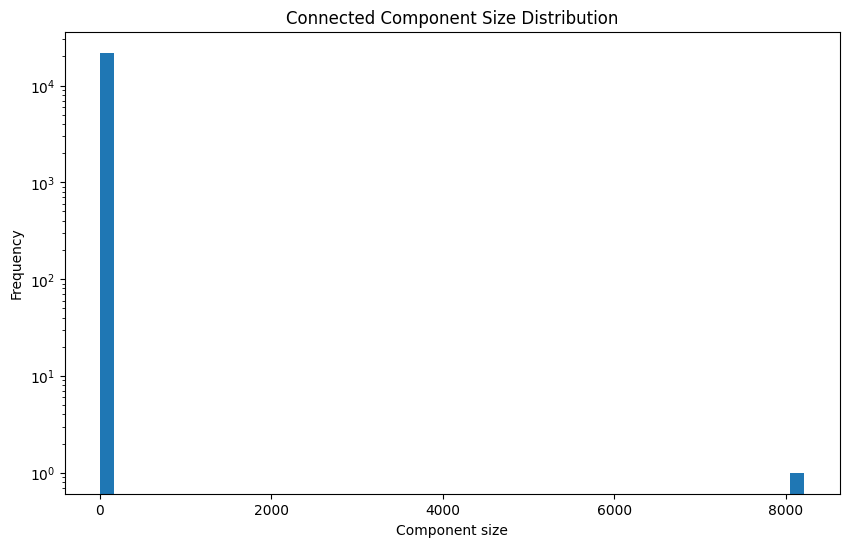

In [10]:
component_sizes = [
    len(component)
    for component in nx.connected_components(G)
]

plt.figure(figsize=(10, 6))
plt.hist(component_sizes, bins=50)
plt.xlabel("Component size")
plt.ylabel("Frequency")
plt.title("Connected Component Size Distribution")
plt.yscale("log")
plt.show()

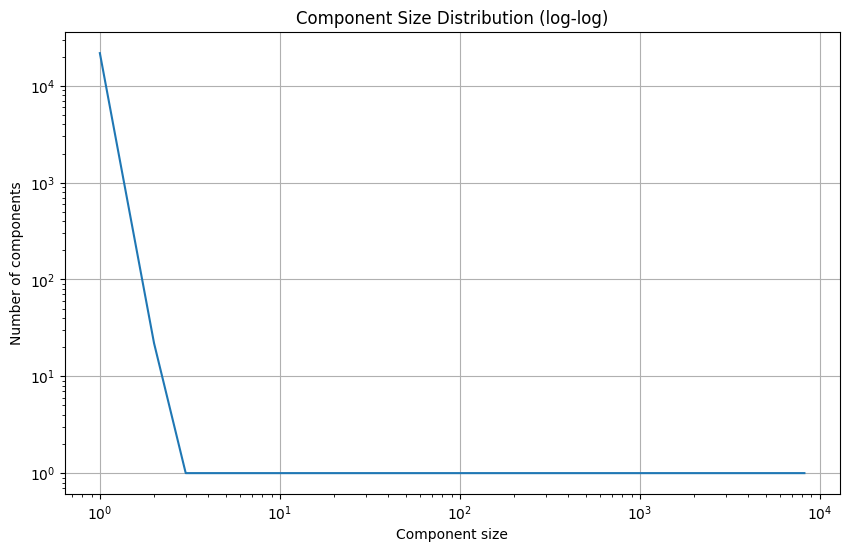

In [11]:
component_sizes = [
    len(component)
    for component in nx.connected_components(G)
]

component_size_counts = pd.Series(component_sizes).value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(
    component_size_counts.index,
    component_size_counts.values
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Component size")
plt.ylabel("Number of components")
plt.title("Component Size Distribution (log-log)")
plt.grid(True)
plt.show()

In [12]:
largest_component = max(
    nx.connected_components(G),
    key=len
)

print(f"Largest component size: {len(largest_component)}")

Largest component size: 8220


# Export

In [13]:
SAMPLE_GRAPH_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

nx.write_graphml(
    G,
    SAMPLE_GRAPH_OUTPUT_PATH
)

print(f"Graph exported to: {SAMPLE_GRAPH_OUTPUT_PATH}")

Graph exported to: C:\Users\PICHAU\Repositories\steam-graph-analysis\data\processed\steam_game_similarity_sample_1pct.graphml


In [14]:
import random
import networkx as nx

# Get the largest connected component
largest_component_nodes = max(
    nx.connected_components(G),
    key=len
)

# Randomly sample nodes from the largest component
sample_size = 300

sample_nodes = random.sample(
    list(largest_component_nodes),
    sample_size
)

# Create visualization subgraph
G_visual = G.subgraph(sample_nodes).copy()

# Ensure output directory exists
SAMPLE_GRAPH_VISUAL_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Export sampled graph for Gephi visualization
nx.write_graphml(
    G_visual,
    SAMPLE_GRAPH_VISUAL_OUTPUT_PATH
)

print(
    f"Sample graph exported to: "
    f"{SAMPLE_GRAPH_VISUAL_OUTPUT_PATH}"
)
print(
    f"Sample nodes: {G_visual.number_of_nodes()}"
)
print(
    f"Sample edges: {G_visual.number_of_edges()}"
)

Sample graph exported to: C:\Users\PICHAU\Repositories\steam-graph-analysis\data\processed\steam_game_similarity_visual_sample_1pct.graphml
Sample nodes: 300
Sample edges: 1018
